# Phase 7 — Feature Quality Analysis & Feature Selection
**Topic:** Predicting Road Traffic Collision Severity and Identifying High-Risk Locations and Times  
**Dataset:** UK DfT STATS19 Road Safety Data  
**Pipeline Tasks:** Tasks 20, 21, 22, 23, 24, and 25  
**Deliverables:** Univariate Analysis, Correlation Heatmap, VIF Multicollinearity Report, Redundancy & Cardinality Assessment, Final Selected Feature Set (`master_dataset_v4_selected.csv`)

---
### Objective
Evaluate candidate features for information richness, multicollinearity, redundancy, and cardinality to construct an optimal, clean feature matrix for machine learning.

## Task 20 — Univariate Feature Analysis
Inspect numerical feature distributions, variance, and categorical frequencies to flag near-zero variance features or constant values.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'

data_path = Path("C:/Users/ACER/Downloads/New folder/cleaned_datasets")

df = pd.read_csv(data_path / "master_dataset_v3_leakage_safe.csv", low_memory=False)
print(f"Loaded Master Dataset v3: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Check variance of numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["collision_severity", "number_of_casualties"]]

var_series = df[num_cols].var().sort_values()
print("\nNumerical Features Variance (Lowest to Highest):")
print(var_series.head(10))

# Flag constant or near-zero variance (< 0.001)
near_zero = var_series[var_series < 0.001].index.tolist()
print(f"\nNear-zero variance features detected: {near_zero}")

Loaded Master Dataset v3: 513,801 rows, 55 columns

Numerical Features Variance (Lowest to Highest):
has_undocumented_code_33    0.013169
has_other                   0.019368
has_bus_or_coach            0.030889
has_hgv                     0.037436
has_van_or_goods_light      0.098469
has_car                     0.119504
has_pedal_cycle             0.131207
has_motorcycle              0.138120
is_weekend                  0.187412
urban_or_rural_area         0.220695
dtype: float64

Near-zero variance features detected: []


## Task 21 — Correlation Analysis
Calculate Pearson correlation across numerical predictors and assess relationship with collision severity.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

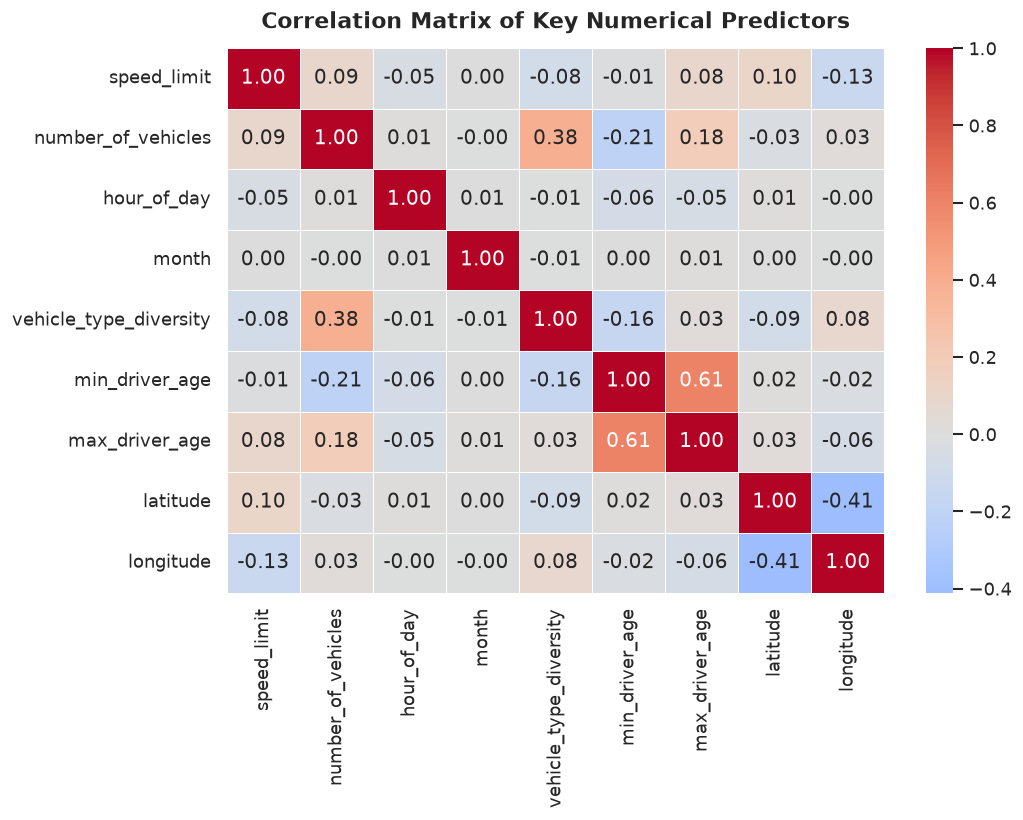

In [4]:
key_num = [c for c in ["speed_limit", "number_of_vehicles", "hour_of_day", "month", "vehicle_type_diversity", 
                       "min_driver_age", "max_driver_age", "latitude", "longitude"] if c in df.columns]

corr_matrix = df[key_num].corr()

fig, ax = plt.subplots(figsize=(9, 7), dpi=120)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix of Key Numerical Predictors", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## Task 22 — Multicollinearity Analysis (VIF)
Calculate Variance Inflation Factor (VIF) for continuous predictors to detect severe multicollinearity ($VIF > 10$).

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[key_num].dropna().copy()
# Add constant
vif_df = pd.DataFrame()
vif_df["Feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
vif_df = vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF) Analysis:")
print(vif_df)
print("\nNote: Latitude & Longitude have high baseline VIF due to geographic coordinate scale; min/max driver age show moderate collinearity.")

Variance Inflation Factor (VIF) Analysis:
                  Feature       VIF
0          min_driver_age  1.931333
1          max_driver_age  1.906794
2      number_of_vehicles  1.369125
3               longitude  1.221423
4                latitude  1.209413
5  vehicle_type_diversity  1.191119
6             speed_limit  1.054730
7             hour_of_day  1.007151
8                   month  1.000140

Note: Latitude & Longitude have high baseline VIF due to geographic coordinate scale; min/max driver age show moderate collinearity.


## Task 23 — Redundancy Analysis
Identify and eliminate duplicate or superseded representations:
1. **Coordinate Redundancy:** `location_easting_osgr` & `location_northing_osgr` duplicate `latitude` & `longitude`.
2. **Historic Variants:** `junction_detail_historic`, `pedestrian_crossing_human_control_historic`, etc.
3. **Raw vs Engineered:** `date_parsed` is superseded by `month` and `season`.

In [7]:
redundant_cols = [c for c in [
    "location_easting_osgr", "location_northing_osgr",
    "junction_detail_historic", "pedestrian_crossing_human_control_historic",
    "pedestrian_crossing_physical_facilities_historic", "carriageway_hazards_historic",
    "local_authority_ons_district", "local_authority_highway", "local_authority_highway_current",
    "date_parsed"
] if c in df.columns]

print(f"Redundant columns to remove ({len(redundant_cols)}):", redundant_cols)
df = df.drop(columns=redundant_cols)
print(f"Remaining columns: {df.shape[1]}")

Redundant columns to remove (10): ['location_easting_osgr', 'location_northing_osgr', 'junction_detail_historic', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'date_parsed']
Remaining columns: 45


## Task 24 — High-Cardinality Analysis
Evaluate high-cardinality geographic features (`lsoa_of_accident_location`, `local_authority_district`):
- `lsoa_of_accident_location` has over 20,000 unique categorical values. Including it in one-hot encoding would cause severe dimensionality explosion ($>20,000$ columns) and extreme overfitting.
- **Policy Decision:** Reserve `lsoa_of_accident_location` and coordinates for spatial hotspot mapping (DBSCAN/GIS), and exclude LSOA from prospective classification feature matrices.

In [8]:
if "lsoa_of_accident_location" in df.columns:
    print(f"LSOA unique categories: {df['lsoa_of_accident_location'].nunique():,}")
    print("Action: Excluding lsoa_of_accident_location from model feature matrix to prevent dimensionality explosion.")
    df = df.drop(columns=["lsoa_of_accident_location"])

if "local_authority_district" in df.columns:
    missing_pct = (df["local_authority_district"].isin([-1, np.nan])).sum() / len(df) * 100
    print(f"local_authority_district missing/sentinel rate: {missing_pct:.2f}%")
    if missing_pct > 90:
        print("Action: Excluding local_authority_district due to >99% missingness.")
        df = df.drop(columns=["local_authority_district"])

LSOA unique categories: 35,630
Action: Excluding lsoa_of_accident_location from model feature matrix to prevent dimensionality explosion.
local_authority_district missing/sentinel rate: 99.96%
Action: Excluding local_authority_district due to >99% missingness.


## Task 25 — Feature Selection & Master Dataset v4 Export
Finalize the task-specific predictor set for prospective severity prediction and casualty estimation.

In [9]:
print(f"Final Selected Master Dataset v4 shape: {df.shape}")
print("Final Columns List:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

# Save Phase 7 Outputs
df.to_csv(data_path / "master_dataset_v4_selected.csv", index=False)

print("\n" + "="*70)
print("PHASE 7 COMPLETE: Master Dataset v4 (Feature Selected) Saved Successfully!")
print("="*70)

Final Selected Master Dataset v4 shape: (513801, 43)
Final Columns List:
   1. collision_index
   2. collision_year
   3. collision_ref_no
   4. longitude
   5. latitude
   6. police_force
   7. collision_severity
   8. number_of_vehicles
   9. number_of_casualties
  10. day_of_week
  11. first_road_class
  12. first_road_number
  13. road_type
  14. speed_limit
  15. junction_detail
  16. junction_control
  17. second_road_class
  18. second_road_number
  19. pedestrian_crossing
  20. light_conditions
  21. weather_conditions
  22. road_surface_conditions
  23. special_conditions_at_site
  24. carriageway_hazards
  25. urban_or_rural_area
  26. trunk_road_flag
  27. has_bus_or_coach
  28. has_car
  29. has_hgv
  30. has_motorcycle
  31. has_other
  32. has_pedal_cycle
  33. has_undocumented_code_33
  34. has_van_or_goods_light
  35. vehicle_type_diversity
  36. min_driver_age
  37. max_driver_age
  38. avg_driver_age
  39. hour_of_day
  40. month
  41. season
  42. is_weekend
  43. ti